# Lecture 11 — Bases of Vector Spaces and Rank-One Matrices

In previous lectures, we studied vector spaces built from vectors in R^n.

In this lecture, we extend these ideas to new kinds of objects:

- matrices
- functions
- constrained vector spaces
- graphs and networks

---

The key idea is that linear algebra is not restricted to arrows or coordinates.

Any collection of objects that supports:

- addition
- scalar multiplication

can behave like a vector space.

We will study how bases, dimensions, and subspaces appear in these new settings.

## Section 1 — Basis for the Space of 3×3 Matrices

Consider the space M of all 3×3 matrices.

Any matrix in this space has 9 entries:

[

[a11 a12 a13],

[a21 a22 a23],

[a31 a32 a33],

]

---

Since each entry can vary independently, we expect the dimension of this space to be 9.

### Basis Matrices

A natural basis for M is obtained by using matrices with:

- one entry equal to 1
- all other entries equal to 0

Each basis matrix activates exactly one position.

In [9]:
import matplotlib.pyplot as plt
import numpy as np
from seaborn.external.husl import lab_e
from sympy import Matrix

basis = []
for i in range(3):
    for j in range(3):
        matrix = Matrix.zeros(3, 3)
        matrix[i, j] = 1
        basis.append(matrix)
        print(f"Entry {i+1, j+1}:")
        display(matrix)

Entry (1, 1):


Matrix([
[1, 0, 0],
[0, 0, 0],
[0, 0, 0]])

Entry (1, 2):


Matrix([
[0, 1, 0],
[0, 0, 0],
[0, 0, 0]])

Entry (1, 3):


...

Matrix([
[0, 0, 0],
[0, 0, 0],
[1, 0, 0]])

Entry (3, 2):


Matrix([
[0, 0, 0],
[0, 0, 0],
[0, 1, 0]])

Entry (3, 3):


Matrix([
[0, 0, 0],
[0, 0, 0],
[0, 0, 1]])

### Visualizing the Basis Matrices

Each basis matrix controls one independent position in the space of 3×3 matrices.

We visualize them as small grids, where:

- bright cell → active entry
- dark cells → zero entries

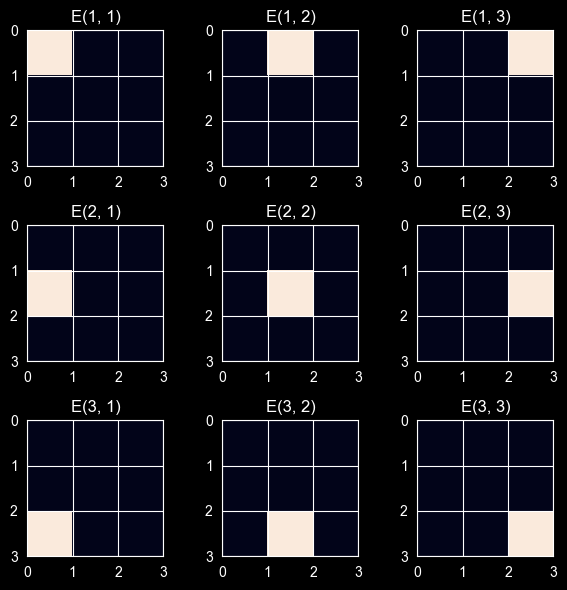

In [23]:
fig, axes = plt.subplots(3, 3, figsize=(6, 6))

for k, matrix in enumerate(basis):
    i = k // 3
    j = k % 3

    ax = axes[i, j]
    ax.imshow(np.array(matrix).astype(float), extent=[0, 3, 3, 0])

    ax.set_title(f"E{i+1, j+1}")

plt.tight_layout()
plt.show()

### Interpretation

Each basis matrix contributes one independent direction in the space M.

Any 3×3 matrix can be built as a linear combination of these basis matrices.

This is why:

dim(M) = 9

### Linear Combination of Basis Matrices

A general matrix can be written as:

a11*E11 + a12*E12 + ... + a33*E33

So the entries of the matrix become the coefficients of the basis expansion.

## Section 2 — Symmetric and Upper Triangular Matrices

Inside the space M of all 3×3 matrices, we can define important subspaces.

We now study two examples:

- Symmetric matrices
- Upper triangular matrices

### Symmetric Matrices

A matrix is symmetric if:

A = A^T

This means the matrix is mirrored across the diagonal.

Example:

[

[a b c],

[b d e],

[c e f],

]

### Dimension of the Symmetric Space

A symmetric 3×3 matrix contains:

- 3 diagonal entries
- 3 independent off-diagonal entries

So:

dim(S) = 6

In [16]:
diagonal_basis = []
for i in range(3):
    matrix = Matrix.zeros(3, 3)
    matrix[i, i] = 1
    diagonal_basis.append(matrix)
    print(f"Entry diagonal {i+1}:")
    display(matrix)

symmetric_basis = []
for i in range(3):
    for j in range(i+1, 3):
        matrix = Matrix.zeros(3, 3)
        matrix[i, j] = 1
        matrix[j, i] = 1
        symmetric_basis.append(matrix)
        print(f"Entry symmetric {i+1, j+1}:")
        display(matrix)

Entry diagonal 1:


Matrix([
[1, 0, 0],
[0, 0, 0],
[0, 0, 0]])

Entry diagonal 2:


Matrix([
[0, 0, 0],
[0, 1, 0],
[0, 0, 0]])

Entry diagonal 3:


...

Matrix([
[0, 1, 0],
[1, 0, 0],
[0, 0, 0]])

Entry symmetric (1, 3):


Matrix([
[0, 0, 1],
[0, 0, 0],
[1, 0, 0]])

Entry symmetric (2, 3):


Matrix([
[0, 0, 0],
[0, 0, 1],
[0, 1, 0]])

### Visualizing Symmetric Basis Matrices

Symmetric matrices reflect across the diagonal.

The basis matrices show the independent positions needed to build any symmetric matrix.

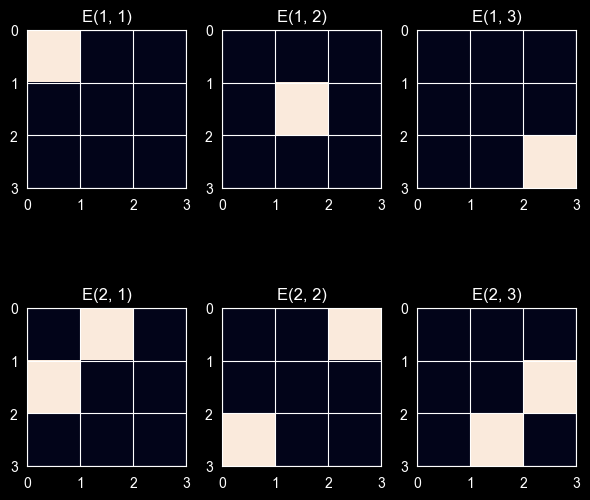

In [24]:
diag_sym_basis = diagonal_basis + symmetric_basis

fig, axes = plt.subplots(2, 3, figsize=(6, 6))

for k, matrix in enumerate(diag_sym_basis):
    i = k // 3
    j = k % 3

    ax = axes[i, j]
    ax.imshow(np.array(matrix).astype(float), extent=[0, 3, 3, 0])

    ax.set_title(f"E{i+1, j+1}")

plt.tight_layout()
plt.show()

### Interpretation

Entries mirrored across the diagonal are not independent.

Changing one automatically determines the other.

This reduces the dimension from 9 to 6.

### Upper Triangular Matrices

An upper triangular matrix has zeros below the diagonal.

Example:

[

[a b c],

[0 d e],

[0 0 f],

]

### Dimension of the Upper Triangular Space

The entries below the diagonal are fixed to zero.

The remaining entries are independent.

So:

dim(U) = 6

In [25]:
upper_right_basis = []

for i in range(3):
    for j in range(i+1, 3):
        matrix = Matrix.zeros(3, 3)
        matrix[i, j] = 1
        upper_right_basis.append(matrix)
        print(f"Entry upper right {i+1, j+1}:")
        display(matrix)

Entry upper right (1, 2):


Matrix([
[0, 1, 0],
[0, 0, 0],
[0, 0, 0]])

Entry upper right (1, 3):


Matrix([
[0, 0, 1],
[0, 0, 0],
[0, 0, 0]])

Entry upper right (2, 3):


Matrix([
[0, 0, 0],
[0, 0, 1],
[0, 0, 0]])

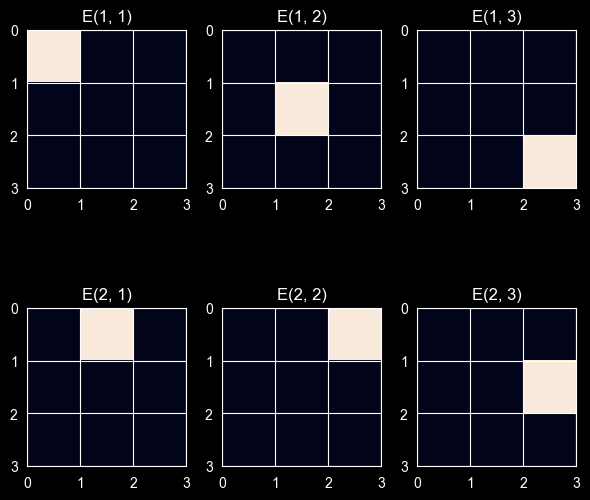

In [26]:
upper_right_diag_basis = diagonal_basis + upper_right_basis

fig, axes = plt.subplots(2, 3, figsize=(6, 6))

for k, matrix in enumerate(upper_right_diag_basis):
    i = k // 3
    j = k % 3

    ax = axes[i, j]
    ax.imshow(np.array(matrix).astype(float), extent=[0, 3, 3, 0])

    ax.set_title(f"E{i+1, j+1}")

plt.tight_layout()
plt.show()

### Interpretation

Upper triangular matrices restrict part of the matrix structure.

Only entries on or above the diagonal can vary independently.

## Section 3 — Intersections and Sums of Subspaces

We now compare two subspaces of M:

- S: symmetric 3×3 matrices
- U: upper triangular 3×3 matrices

Both are subspaces of the larger space M of all 3×3 matrices.
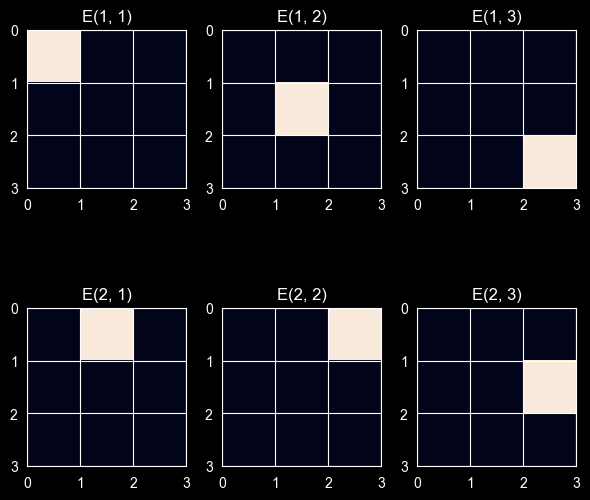

### Intersection of S and U

The intersection S ∩ U contains matrices that are both:

- symmetric
- upper triangular

A matrix that is symmetric cannot have entries below the diagonal unless the matching entries above the diagonal also exist.

But an upper triangular matrix has zeros below the diagonal.

So the only matrices that satisfy both conditions are diagonal matrices.

### Result

S ∩ U = diagonal 3×3 matrices

The diagonal space has three independent entries.

So:

dim(S ∩ U) = 3

In [29]:
for k, m in enumerate(diagonal_basis):
    i = k // 3
    j = k % 3

    print(f"Entry diagonal {i+1, j+1}:")
    display(m)

Entry diagonal (1, 1):


Matrix([
[1, 0, 0],
[0, 0, 0],
[0, 0, 0]])

Entry diagonal (1, 2):


Matrix([
[0, 0, 0],
[0, 1, 0],
[0, 0, 0]])

Entry diagonal (1, 3):


Matrix([
[0, 0, 0],
[0, 0, 0],
[0, 0, 1]])

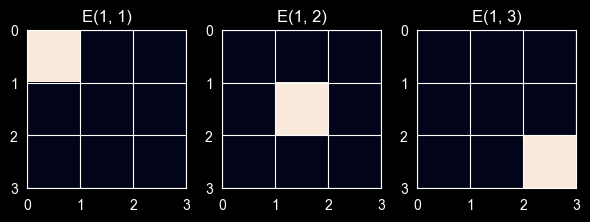

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(6, 6))

for k, matrix in enumerate(diagonal_basis):
    ax = axes[k]
    ax.imshow(np.array(matrix).astype(float), extent=[0, 3, 3, 0])
    ax.set_title(f"E{1, k+1}")

plt.tight_layout()
plt.show()

### Sum of Subspaces

The sum S + U means:

all matrices that can be written as:

s + u

where:

- s is symmetric
- u is upper triangular

### Result

For 3×3 matrices:

S + U = M

That means every 3×3 matrix can be written as:

symmetric matrix + upper triangular matrix

So:

dim(S + U) = 9

### Dimension Formula

For two subspaces S and U:

dim(S) + dim(U) = dim(S ∩ U) + dim(S + U)

In this example:

dim(S) = 6
dim(U) = 6
dim(S ∩ U) = 3
dim(S + U) = 9

So:

6 + 6 = 3 + 9

### Interpretation

When two subspaces overlap, their dimensions cannot simply be added.

The shared part is counted twice.

The formula corrects this by subtracting the overlap through the intersection term.

## Section 4 — Function Spaces

So far, our vectors were:

- columns of numbers
- matrices

Now we study another type of vector:

functions.

---

Functions can also form vector spaces because we can:

- add functions
- multiply functions by constants

### Example — Differential Equation

Consider the equation:

y'' + y = 0

We want to find all functions y(x) that satisfy this equation.

### Two Solutions

Two important solutions are:

- cos(x)
- sin(x)

Both satisfy:

y'' + y = 0

In [38]:
from sympy import symbols, cos, sin, diff, lambdify

x = symbols('x')

y_cos = cos(x)
y_sin = sin(x)

y_cos_dd = diff(y_cos, x, 2)
y_sin_dd = diff(y_sin, x, 2)

print("cos second derivative:")
display(y_cos_dd)

print("sin second derivative:")
display(y_sin_dd)

print("cos verification:")
display(y_cos_dd + y_cos)

print("sin verification:")
display(y_sin_dd + y_sin)

cos second derivative:


-cos(x)

sin second derivative:


-sin(x)

cos verification:


0

sin verification:


0

### Visualizing the Solutions

The functions cos(x) and sin(x) represent two independent solution directions.

Any solution of the differential equation can be built from combinations of them.

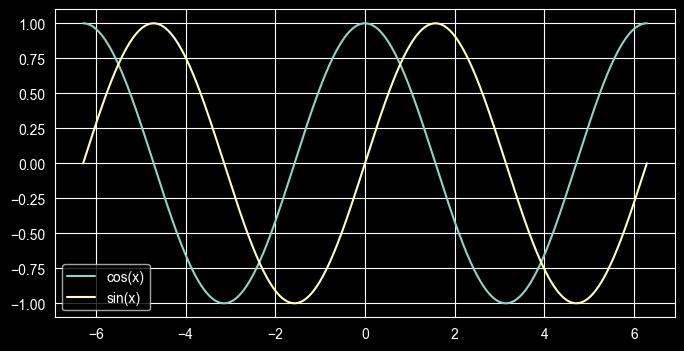

In [39]:
x_vals = np.linspace(-2*np.pi, 2*np.pi, 500)

cos_vals = lambdify(x, y_cos, "numpy")(x_vals)
sin_vals = lambdify(x, y_sin, "numpy")(x_vals)

plt.figure(figsize=(8, 4))
plt.plot(x_vals, cos_vals, label="cos(x)")
plt.plot(x_vals, sin_vals, label="sin(x)")

plt.legend()
plt.grid(True)
plt.show()

### Complete Solution

Every solution of:

y'' + y = 0

can be written as:

y(x) = c1*cos(x) + c2*sin(x)

---

So:

- cos(x) and sin(x) form a basis
- the solution space has dimension 2

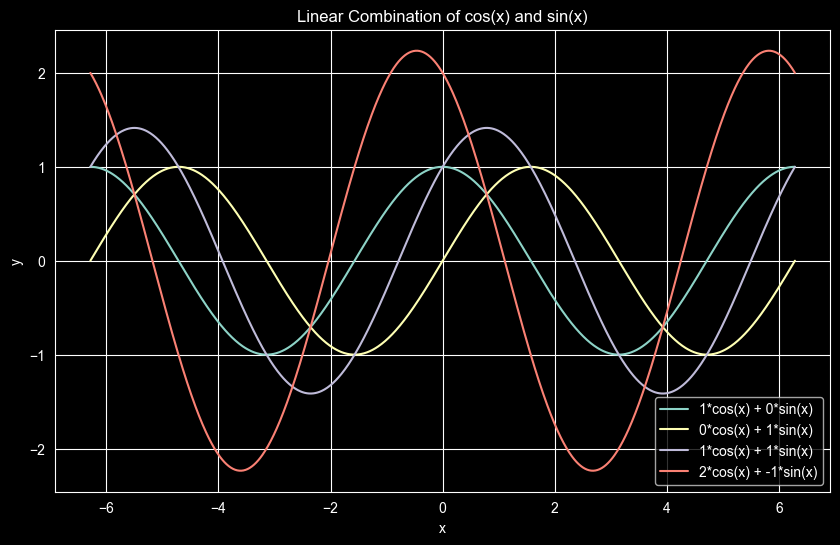

In [45]:
x_vals = np.linspace(-2*np.pi, 2*np.pi, 1000)

coefficients = [
    (1, 0),
    (0, 1),
    (1, 1),
    (2, -1)
]

plt.figure(figsize=(10, 6))
for c1, c2 in coefficients:
    y = c1 * np.cos(x_vals) + c2 * np.sin(x_vals)
    plt.plot(x_vals, y, label=f"{c1}*cos(x) + {c2}*sin(x)")

plt.title("Linear Combination of cos(x) and sin(x)")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.legend()
plt.show()

### Interpretation

The solutions behave like vectors:

- they can be added
- scaled
- combined

The basis functions:

- cos(x)
- sin(x)

generate the entire solution space.

### Dimension of the Solution Space

There are two independent basis functions:

- cos(x)
- sin(x)

So:

dimension = 2

## Section 5 — Rank-One Matrices

We now study matrices with the simplest possible nonzero structure:

rank-one matrices.

A rank-one matrix has only one independent row and one independent column.

### Example

Consider the matrix:

A =
[

[1  4  5],

[2  8 10],

]

The second row is:

2 × (first row)

So the rows are dependent.

---

This means:

rank(A) = 1

In [49]:
A = Matrix([
    [1, 4, 5],
    [2, 8, 10]
], dtype=float)
print("A: ")
A

A: 


Matrix([
[1, 4,  5],
[2, 8, 10]])

In [52]:
rank = A.rank()
print("A rank: ", rank)

A rank:  1


### Outer Product Representation

A rank-one matrix can be written as:

A = u v^T

where:

- u is a column vector
- v^T is a row vector

### Constructing A from Two Vectors

For this matrix:

u =
[<br>
[1],<br>
[2],<br>
]

v^T =
[1 4 5]

Then:

A = u v^T

In [58]:
u = Matrix([1,2])
u

Matrix([
[1],
[2]])

In [64]:
v = Matrix([1, 4, 5])
u_T = v.transpose()
u_T

Matrix([[1, 4, 5]])

In [66]:
A_rank1 = u @ u_T
print("A with Rank 1: ")
A_rank1

A with Rank 1: 


Matrix([
[1, 4,  5],
[2, 8, 10]])

### Visualizing a Rank-One Matrix

A rank-one matrix is generated from:

- one column direction
- one row direction

Every row is a scaled copy of one row vector.

Every column is a scaled copy of one column vector.

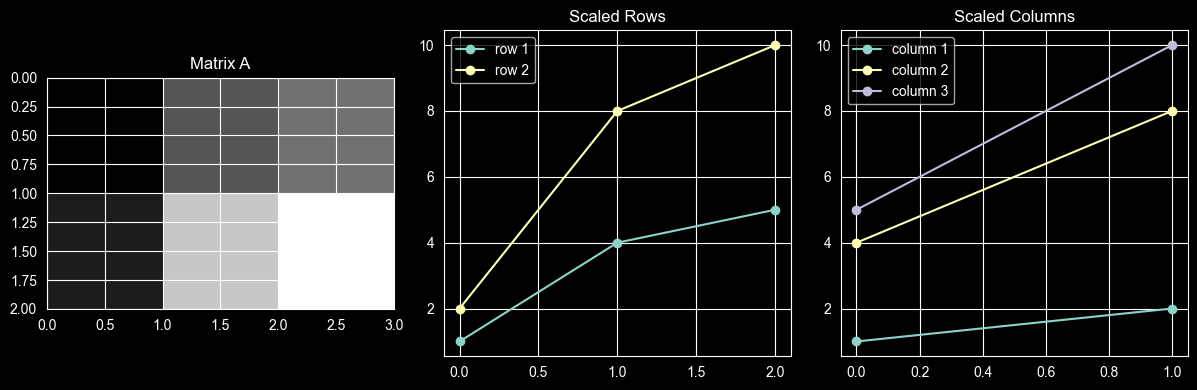

In [71]:
A_np = np.array(A).astype(float)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(A_np, cmap="gray", extent=[0, 3, 2, 0])
axes[0].set_title("Matrix A")

for i in range(A_np.shape[0]):
    axes[1].plot(A_np[i], marker='o', label=f"row {i+1}")
axes[1].set_title("Scaled Rows")
axes[1].legend()
axes[1].grid(True)

for j in range(A_np.shape[1]):
    axes[2].plot(
        A_np[:, j], marker='o', label=f"column {j+1}"
    )
axes[2].set_title("Scaled Columns")
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

### Interpretation

A rank-one matrix contains only one independent direction.

All rows are multiples of one row vector.

All columns are multiples of one column vector.

### Important Observation

The set of all rank-one matrices is not a subspace.

### Why Not?

A subspace must be closed under addition.

But:

rank-one matrix + rank-one matrix

can produce a matrix with rank 2.

In [77]:
u1 = Matrix([1, 2])
u2 = Matrix([1, 0])

v1_T = Matrix([1, 4, 5]).transpose()
v2_T = Matrix([0, 1, 0]).transpose()

A1 = u1 @ v1_T
A2 = u2 @ v2_T

A_sum = A1 + A2

print("A1: ")
display(A1)
print("A1 Rank:", A1.rank())

print("\nA2: ")
display(A2)
print("A2 Rank:", A2.rank())

print("\nA_sum: ")
display(A_sum)
print("A_sum Rank:", A_sum.rank())

A1: 


Matrix([
[1, 4,  5],
[2, 8, 10]])

A1 Rank: 1

A2: 


Matrix([
[0, 1, 0],
[0, 0, 0]])

A2 Rank: 1

A_sum: 


Matrix([
[1, 5,  5],
[2, 8, 10]])

A_sum Rank: 2


### Interpretation

Even though each matrix individually has rank 1, their sum can create new independent directions.

So the set is not closed under addition.

Therefore:

rank-one matrices do not form a subspace.

## Section 6 — A Constraint Subspace in R^4

Consider the set of all vectors in R^4 satisfying:

v1 + v2 + v3 + v4 = 0

This condition restricts the vectors to a smaller space inside R^4.

### Matrix Form

We can write the constraint as:

A v = 0

where:

A = [1 1 1 1]

and:

v =
[v1</br>
 v2</br>
 v3</br>
 v4]

---

So this space is the null space of A.

In [78]:
A = Matrix([
    [1.0, 1.0, 1.0, 1.0]
])
A

Matrix([[1.0, 1.0, 1.0, 1.0]])

In [79]:
A.rank()

1

### Dimension of the Null Space

The matrix A has:

- n = 4 columns
- rank = 1

So:

dim N(A) = n - r = 4 - 1 = 3

### Solving the Constraint

From:

v1 + v2 + v3 + v4 = 0

we solve for the pivot variable:

v1 = -v2 - v3 - v4

The remaining variables are free.

In [81]:
basis_vectors = [
    Matrix([-1, 1, 0, 0]), # v2
    Matrix([-1, 0, 1, 0]), # v3
    Matrix([-1, 0, 0, 1]), # v4
]

### Basis for the Subspace

These vectors form a basis for the null space.

Any vector satisfying:

v1 + v2 + v3 + v4 = 0

can be written as a combination of them.

In [86]:
print("A: ")
display(A)
print()
for v in basis_vectors:
    print(A @ v)

A: 


Matrix([[1.0, 1.0, 1.0, 1.0]])


Matrix([[0]])
Matrix([[0]])
Matrix([[0]])


### Interpretation

The equation:

v1 + v2 + v3 + v4 = 0

removes one independent direction from R^4.

So the remaining space has dimension 3.

### Connection to Previous Lectures

For this matrix:

- dim C(A) = 1
- dim N(A) = 3

and:

1 + 3 = 4 = n

---

Since A has only one row:

- C(A) lives in R^1
- N(A^T) = {0}

## Section 7 — Graphs and Networks

Linear algebra can also describe networks and connections.

A graph consists of:

- nodes
- edges

Nodes represent objects.

Edges represent relationships or connections between them.

### Example — Student Network

We can represent students as nodes.

Connections between students become edges.

The edges may also contain:

- distances
- weights
- strengths of connection

### Why Graphs Matter

Graphs appear in many applications:

- social networks
- transportation systems
- recommendation systems
- communication networks

Linear algebra provides tools to study these structures mathematically.

### Visualizing a Graph

We create a small network where:

- circles represent nodes
- lines represent edges

The graph structure captures relationships between connected objects.

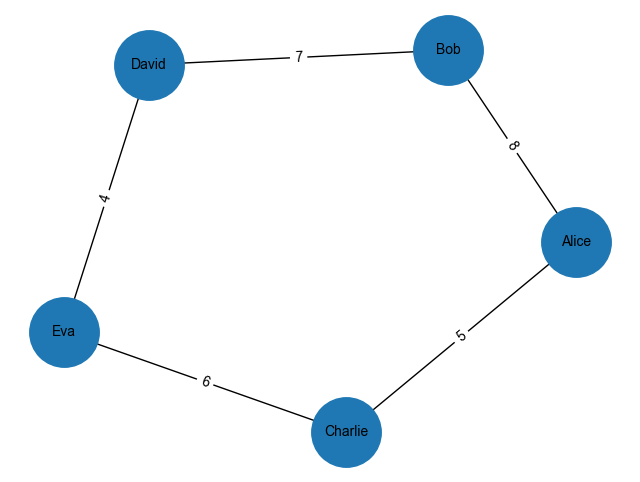

In [93]:
import networkx as nx

G = nx.Graph()

students = ["Alice", "Bob", "Charlie", "David", "Eva"]
G.add_nodes_from(students)

G.add_edge("Alice", "Bob", weight=8)
G.add_edge("Alice", "Charlie", weight=5)
G.add_edge("Bob", "David", weight=7)
G.add_edge("Charlie", "Eva", weight=6)
G.add_edge("David", "Eva", weight=4)

pos = nx.spring_layout(G, seed=42)

fig, axes = plt.subplots(figsize=(8, 6))
nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=2500,
    font_size=10,
    ax=axes
)

edge_labels = nx.get_edge_attributes(G, "weight")
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, ax=axes)
axes.set_axis_off()
plt.show()


### Interpretation

The graph transforms relationships into mathematical structure.

Later, matrices will be used to represent:

- connectivity
- flow
- distances
- movement through networks

## Conclusion — Bases in New Vector Spaces

In this lecture, we expanded linear algebra beyond vectors in R^n.

We studied spaces formed by:

- matrices
- functions
- constrained vectors
- graphs and networks

---

### 1. Matrix Spaces

The space of all 3×3 matrices has dimension 9.

Subspaces such as:

- symmetric matrices
- upper triangular matrices

have their own bases and dimensions.

### 2. Subspace Relationships

We studied intersections and sums of subspaces:

- S ∩ U → diagonal matrices
- S + U → all 3×3 matrices

and verified the dimension formula:

dim(S) + dim(U)
=
dim(S ∩ U) + dim(S + U)

### 3. Function Spaces

Solutions of differential equations also form vector spaces.

For:

y'' + y = 0

the functions:

- cos(x)
- sin(x)

form a basis for the solution space.

### 4. Rank-One Matrices

Rank-one matrices can be written as:

A = u v^T

They contain only one independent row and one independent column.

However, rank-one matrices do not form a subspace because they are not closed under addition.

### 5. Constraint Spaces

Constraints such as:

v1 + v2 + v3 + v4 = 0

create subspaces through null spaces.

The dimension measures the remaining freedom after applying the constraint.

### Final Insight

Linear algebra studies structure.

The objects may change:

- vectors
- matrices
- functions
- networks

but the central ideas remain the same:

- basis
- dimension
- independence
- subspaces
- linear combinations